In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10


In [5]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

#Normalization 0-255 to 0,1
x_train = x_train / 255.0
x_test = x_test / 255.0


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])


model = models.Sequential()

# Add augmentation as first layer
model.add(data_augmentation)

# Conv Block 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
'''32 filters, 3x3 size me, thode features sikhe, increase filters to learn complex features
'''
model.add(layers.MaxPooling2D((2,2)))
'''pooling me 2x2 area me max ele lekr pooling'''
model.add(layers.Dropout(0.25))
'''after processing - dropout'''

# Conv Block 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# Fully Connected Layer = Dense Layer
'''Every neuron connects to all neurons from previous layer.
'''
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu')) #128 = neurons in that layer
model.add(layers.Dropout(0.5))

#Output layer
model.add(layers.Dense(10, activation='softmax')) #10=output classes

''' Conv layers → Extract features
Dense(128) → Understand features
'''

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_test, y_test)
)


loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.2659 - loss: 1.9830 - val_accuracy: 0.4399 - val_loss: 1.5282
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4219 - loss: 1.5940 - val_accuracy: 0.5197 - val_loss: 1.3229
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.4679 - loss: 1.4851 - val_accuracy: 0.5310 - val_loss: 1.2722
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.4881 - loss: 1.4284 - val_accuracy: 0.5670 - val_loss: 1.2345
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5067 - loss: 1.3820 - val_accuracy: 0.5786 - val_loss: 1.1901
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5180 - loss: 1.3508 - val_accuracy: 0.5941 - val_loss: 1.1402
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5223 - loss: 1.3358 - val_accuracy: 0.6046 - val_loss: 1.1223
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5353 - loss: 1.3096 - val_accurac

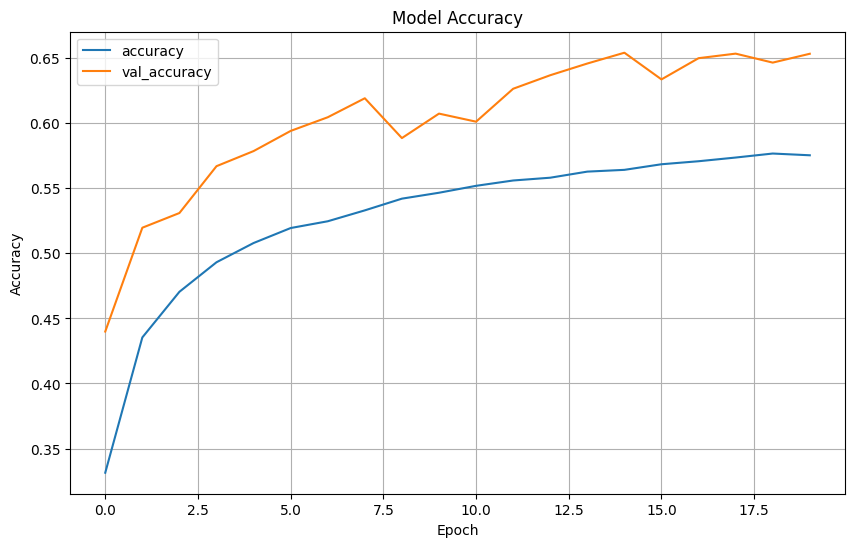

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label=['accuracy'])
plt.plot(history.history['val_accuracy'], label=['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()